In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

# DATA_SOURCE = "Preop + Intraop"
# output_pkl = '/home/server/Projects/data/AKI/results/tabular_combined.pkl'

DATA_SOURCE = "Preop"
output_pkl = '/home/server/Projects/data/AKI/results/tabular_preop.pkl'

# DATA_SOURCE = "Intraop"
# output_pkl = '/home/server/Projects/data/AKI/results/tabular_intraop.pkl'

df = pd.read_pickle(output_pkl)

# make names more readable
model_translate = {
    'base': 'base',
    'log_reg': 'Logistic Regression',
    'lin_reg': 'Linear Regression',
    'autogluon': 'AutoGluon',
    'xgb': 'XGBoost',
    'svm': 'SVM',
    'mlp': 'MLP',
    'rf': 'Random Forest',
    'knn': 'KNN',
    'asa': 'ASA',
}
df['model_name'] = df['model_name'].map(model_translate)

In [2]:
df[df['model_name'] == 'base']['y_pred_binary'].values[0][0].shape

(11545,)

In [3]:
df[df['model_name'] == 'ASA']['y_prob'].values[0][0].shape

(11545,)

In [4]:
df

,Precision,Sensitivity,Accuracy,rc_auc,pr_auc,Specificity,Negative Predictive Value,F1 Score,y_pred_binary,y_prob,model_name
0,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[False, False, False, True, False, False, Fal...","[[False, False, False, True, False, False, Fal...",base
1,"[0.19236417033773862, 0.19848430169613857, 0.1...","[0.7528735632183908, 0.7890961262553802, 0.747...","[0.7945430922477262, 0.794889562581204, 0.8, 0...","[0.8441683273949715, 0.8545451852228049, 0.841...","[0.2558983729627248, 0.26097916667394355, 0.25...","[0.7972163333026085, 0.7952617994100295, 0.803...","[0.9805010769753996, 0.9832459539548667, 0.980...","[0.3064327485380117, 0.31718569780853517, 0.31...","[[True, False, True, False, False, True, False...","[[0.5389874485612498, 0.24963695502435856, 0.9...",Logistic Regression
2,"[0.15903890160183065, 0.16628041714947855, 0.1...","[0.7988505747126436, 0.8235294117647058, 0.771...","[0.7332178432221741, 0.7400606323083586, 0.744...","[0.8206058506372217, 0.8309495393236077, 0.820...","[0.22269942297528714, 0.2146130576182482, 0.22...","[0.7290072817771223, 0.7346976401179941, 0.742...","[0.9826065349732886, 0.984801680464599, 0.9806...","[0.2652671755725191, 0.2766931790792962, 0.266...","[[True, False, True, False, False, True, False...","[[0.6015775139101682, 0.4349030877112754, 0.58...",Linear Regression
3,"[0.8, 0.4, 0.6, 0.7142857142857143, 0.66666666...","[0.005747126436781609, 0.005738880918220947, 0...","[0.9399740147249892, 0.9394543092247726, 0.939...","[0.8424396602049239, 0.8427206464282238, 0.820...","[0.2769674351566565, 0.26492365401977785, 0.24...","[0.9999078256060466, 0.9994469026548672, 0.999...","[0.9400346620450607, 0.9399219765929779, 0.940...","[0.011412268188302425, 0.011315417256011316, 0...","[[False, False, False, False, False, False, Fa...","[[0.09007031470537186, 0.06581950187683105, 0....",AutoGluon
4,"[0.4077868852459016, 0.37732342007434944, 0.39...","[0.2859195402298851, 0.29124820659971307, 0.29...","[0.9319185794716327, 0.9281940233867475, 0.930...","[0.8443898902700923, 0.8414394761789887, 0.838...","[0.3422290702882103, 0.3093950320825697, 0.321...","[0.9733616001474791, 0.9691187315634219, 0.971...","[0.9550510988514064, 0.9551194694285454, 0.955...","[0.33614864864864863, 0.3287449392712551, 0.33...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,...","[[0.01810354, 0.09070274, 0.43062863, 0.008716...",XGBoost
5,"[0.167687235044748, 0.167192429022082, 0.17601...","[0.5114942528735632, 0.5322812051649928, 0.527...","[0.8174967518406236, 0.8116933737548723, 0.822...","[0.7226423485187998, 0.7222302678356041, 0.728...","[0.30869483631825473, 0.31806385871496157, 0.3...","[0.8371278458844134, 0.8296460176991151, 0.841...","[0.9639142432604543, 0.9650439631138752, 0.965...","[0.25257183398368216, 0.2544581618655693, 0.26...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[1.0, 0.0, 0.9772727272727273, 0.0, 0.9772727...",SVM
6,"[0.1848357791754018, 0.17749196141479098, 0.19...","[0.7600574712643678, 0.7919655667144907, 0.728...","[0.78345604157644, 0.7658726721524469, 0.79766...","[0.8420457338617998, 0.8239731328534003, 0.825...","[0.3184735271534786, 0.28091678622396987, 0.28...","[0.7849571389068117, 0.7641961651917404, 0.802...","[0.9807670160082921, 0.982809721398933, 0.9787...","[0.29735806632939854, 0.2899921197793538, 0.30...","[[True, False, True, False, False, False, Fals...","[[0.7947607165292724, 0.2427214225191303, 0.92...",MLP
7,"[0.6323529411764706, 0.4626865671641791, 0.631...","[0.1235632183908046, 0.08895265423242468, 0.10...","[0.9428323949761802, 0.9387613685578172, 0.94

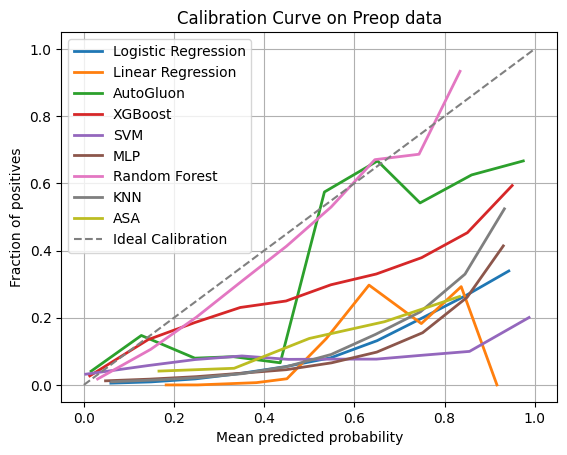

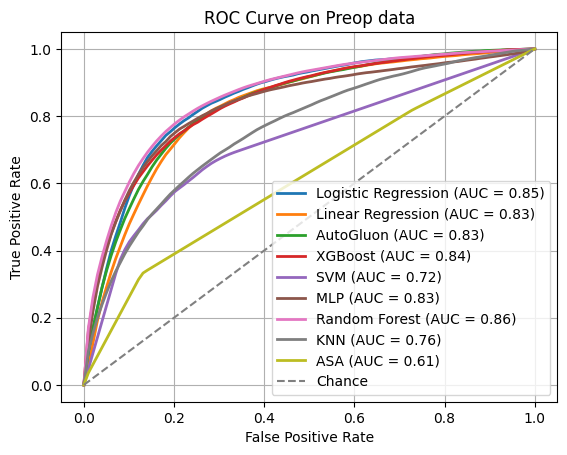

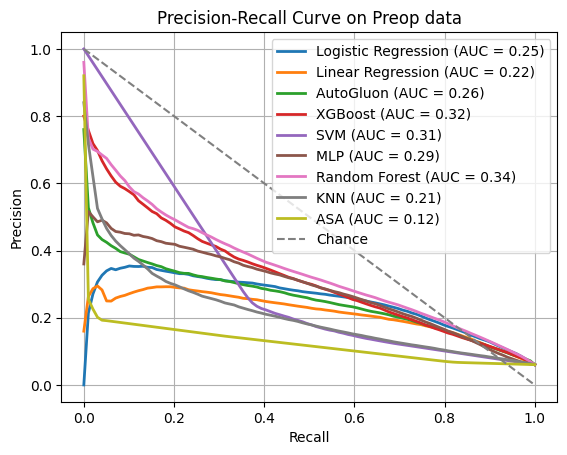

In [6]:
# plot avged curves
def plot_calibration_curves(df):
    plt.figure()

    model_names = df['model_name'].values.tolist()
    model_names.remove('base')
    for model_name in model_names:

        y_true = np.concatenate(df[df['model_name'] == 'base']['y_pred_binary'].values[0])
        y_prob = np.concatenate(df[df['model_name'] == model_name]['y_prob'].values[0])
        
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')


        plt.plot(prob_pred, prob_true, label=f'{model_name}', lw=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal Calibration')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title(f'Calibration Curve on {DATA_SOURCE} data')
    plt.legend(loc='upper left')
    plt.grid(True)

def plot_roc_curve(df):
    plt.figure()

    model_names = df['model_name'].values.tolist()
    model_names.remove('base')
    for model_name in model_names:
        df_base = df[df['model_name'] == 'base'].iloc[0]
        df_row = df[df['model_name'] == model_name].iloc[0]

        # Set up common FPR points to interpolate all curves onto
        mean_fpr = np.linspace(0, 1, 100)
        tprs = []
        aucs = []

        # Collect TPRs and AUCs from all folds/splits
        for i in range(df_row['y_prob'].shape[0]):
            y_prob = df_row['y_prob'][i]
            y_binary_test = df_base['y_pred_binary'][i]

            fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0  # Ensure it starts at 0
            tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

        # Compute the mean and std across interpolated TPRs
        mean_tpr = np.mean(tprs, axis=0)
        std_tpr = np.std(tprs, axis=0)
        mean_auc = auc(mean_fpr, mean_tpr)

        # Plot the averaged ROC curve
        plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC = {mean_auc:.2f})', lw=2)
        # plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='lightblue', alpha=0.4)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve on {DATA_SOURCE} data')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

def plot_pr_curve(df):
    plt.figure()

    model_names = df['model_name'].values.tolist()
    model_names.remove('base')
    for model_name in model_names:
        df_base = df[df['model_name'] == 'base'].iloc[0]
        df_row = df[df['model_name'] == model_name].iloc[0]

        mean_recall = np.linspace(0, 1, 100)
        precisions = []
        pr_aucs = []

        for i in range(df_row['y_prob'].shape[0]):
            y_prob = df_row['y_prob'][i]
            y_binary_test = df_base['y_pred_binary'][i]

            precision, recall, _ = precision_recall_curve(y_binary_test, y_prob)
            interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])  # Make sure recall is increasing
            precisions.append(interp_prec)
            pr_aucs.append(auc(recall, precision))

        mean_prec = np.mean(precisions, axis=0)
        std_prec = np.std(precisions, axis=0)
        mean_pr_auc = auc(mean_recall, mean_prec)

        plt.plot(mean_recall, mean_prec, label=f'{model_name} (AUC = {mean_pr_auc:.2f})', lw=2)
        # plt.fill_between(mean_recall, mean_prec - std_prec, mean_prec + std_prec, alpha=0.4, color='navajowhite')
    plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label='Chance')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve on {DATA_SOURCE} data')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()







plot_calibration_curves(df)
plot_roc_curve(df)
plot_pr_curve(df)

In [ ]:
for model_name in model_names:
    plot_avg_calibration_curve(df, model_name)
    plot_avg_roc_curve(df, model_name)
    plot_avg_pr_curve(df, model_name)

In [ ]:
# print out performance metrics

if 'y_pred_binary' in df.columns:
    df = df.drop(columns=['y_pred_binary'])
if 'y_prob' in df.columns:
    df = df.drop(columns=['y_prob'])
model_names = df['model_name'].values.tolist()
model_names.remove('base')
performance_metrics = df.columns.values.tolist()
performance_metrics.remove('model_name')

for model_name in model_names:
    df_row = df[df['model_name'] == model_name].iloc[0]
    print(model_name)
    for performance_metric in performance_metrics:
        arr = df_row[performance_metric]

        mean = np.mean(arr)
        sem = stats.sem(arr)
        confidence = 0.95
        n = len(arr)
        dof = n - 1
        ci = stats.t.interval(confidence, dof, loc=mean, scale=sem)
        print(f'{ci[0]:0.06f}\t{mean:0.06f}\t{ci[1]:0.06f}')
    print()
